In [29]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.utils import resample
import pandas as pd

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve, auc
from sklearn.inspection import permutation_importance

## Binary Classification Using Random Forest

### Prepare data

In [10]:
k = 7
data_type = 'functions'
results_path = f"../results/{data_type}/random_split/nmf_trained/nsig_{k}"

random_seed = 42

In [5]:
# Load results from NMF
H_train_path = f'{results_path}/best_run/H_train_{k}.csv'
H_test_path = f'{results_path}/best_run/H_test_{k}.csv'

H_train = pd.read_csv(H_train_path, index_col=0)
H_test = pd.read_csv(H_test_path, index_col=0)

H_train.index = [i for i in range(1, k + 1)]
H_test.index = [i for i in range(1, k + 1)]

metadata = pd.read_csv("../data/metadata.tsv", sep="\t", index_col=None)
metadata = metadata.set_index('sample_id')

In [6]:
# By normalizing the H matrix column-wise, we obtained the relative abundance of ES in each sample. We define as primary ES the ES of a sample with the highest relative abundance.
H_train_norm = H_train.div(H_train.sum(axis=0), axis=1) * 100
H_test_norm = H_test.div(H_test.sum(axis=0), axis=1) * 100

H_train_norm = H_train_norm.T
H_test_norm = H_test_norm.T

In [ ]:
# Get information about health status, encode as 0 or 1
y_train = (~metadata.loc[H_train_norm.index, "disease"].astype(str).str.lower().eq("healthy")).astype(int)
y_test = (~metadata.loc[H_test_norm.index, "disease"].astype(str).str.lower().eq("healthy")).astype(int)

In [11]:
# Balance train
train_0 = H_train_norm.loc[y_train == 0] # healthy
train_1 = H_train_norm.loc[y_train == 1] # sick

n_train = min(len(train_0), len(train_1)) # subset size

train_0_subset = resample(train_0,
                       replace=False,
                       n_samples=n_train,
                       random_state=random_seed)

train_1_subset = resample(train_1,
                       replace=False,
                       n_samples=n_train,
                       random_state=random_seed)

H_train_balanced = pd.concat([train_0_subset, train_1_subset])
H_train_balanced = H_train_balanced.sample(frac=1, random_state=42) # Shuffle

y_train_balanced = y_train.loc[H_train_balanced.index]

In [12]:
# Balance test
test_0 = H_test_norm.loc[y_test == 0] # healthy
test_1 = H_test_norm.loc[y_test == 1] # sick

n_test = min(len(test_0), len(test_1)) # subset size

test_0_subset = resample(test_0,
                       replace=False,
                       n_samples=n_test,
                       random_state=random_seed)

test_1_subset = resample(test_1,
                       replace=False,
                       n_samples=n_test,
                       random_state=random_seed)

H_test_balanced = pd.concat([test_0_subset, test_1_subset])
H_test_balanced = H_test_balanced.sample(frac=1, random_state=42) # Shuffle

y_test_balanced = y_test.loc[H_test_balanced.index]


In [ ]:
print("Original train:")
print(y_train.value_counts())

print("\nBalanced train:")
print(y_train_balanced.value_counts())

print("\nOriginal test:")
print(y_test.value_counts())

print("\nBalanced test:")
print(y_test_balanced.value_counts())

print("\nShapes:")
print("H_train_balanced:", H_train_balanced.shape)
print("y_train_balanced:", y_train_balanced.shape)
print("H_test_balanced: ", H_test_balanced.shape)
print("y_test_balanced: ", y_test_balanced.shape)

Original train:
disease
0    7816
1    4457
Name: count, dtype: int64

Balanced train:
disease
0    4457
1    4457
Name: count, dtype: int64

Original test:
disease
0    2633
1    1458
Name: count, dtype: int64

Balanced test:
disease
1    1458
0    1458
Name: count, dtype: int64

Shapes:
H_train_balanced: (8914, 7)
y_train_balanced: (8914,)
H_test_balanced:  (2916, 7)
y_test_balanced:  (2916,)


### Random Forest

In [16]:
rf = RandomForestClassifier(n_estimators=1000, max_features="sqrt", random_state=random_seed, n_jobs=-1)
rf.fit(H_train_balanced, y_train_balanced)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",1000
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the tota

In [17]:
y_pred = rf.predict(H_test_balanced)
y_prob = rf.predict_proba(H_test_balanced)[:, 1]

In [18]:
# Evaluate on H_test

print("Accuracy:", round(accuracy_score(y_test_balanced, y_pred), 3))

print("ROC AUC:", round(roc_auc_score(y_test_balanced, y_prob), 3))

print(classification_report(y_test_balanced, y_pred, target_names=["healthy", "unhealthy"]))

Accuracy: 0.662
ROC AUC: 0.72
              precision    recall  f1-score   support

     healthy       0.66      0.66      0.66      1458
   unhealthy       0.66      0.67      0.66      1458

    accuracy                           0.66      2916
   macro avg       0.66      0.66      0.66      2916
weighted avg       0.66      0.66      0.66      2916



In [19]:
def plot_cm(cm, figname):
    cm_per = (cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100)

    plt.figure(figsize=(5, 4))

    sns.heatmap(cm_per,
                annot=False,
                cmap="Blues",
                vmin=0,
                vmax=100,
                fmt=".1f",
                cbar_kws={"label": "Percentage (%)"})

    # Count + % to each cell
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):

            plt.text(x=j + 0.5,
                     y=i + 0.5,
                     s=f"{cm[i, j]:,}\n({cm_per[i, j]:.1f}%)",
                     ha="center",
                     va="center",
                     fontsize=12,
                     color="white" if (i == 0 and j == 0) or (i == 1 and j == 1) else "black")

    plt.xlabel("Predicted status", fontsize=12)
    plt.ylabel("True status", fontsize=12)
    plt.xticks([0.5, 1.5], ["Healthy", "Unhealthy"], fontsize=12)
    plt.yticks([0.5, 1.5], ["Healthy", "Unhealthy"], rotation=90, fontsize=12)

    plt.tight_layout()
    plt.savefig(figname, dpi=300)
    plt.show()

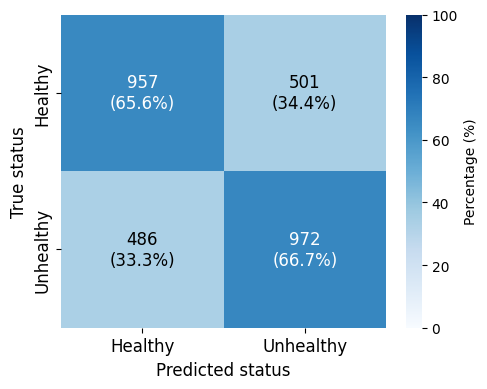

In [ ]:
cm = confusion_matrix(
    y_test_balanced,
    y_pred
)

plot_cm(cm, '../images/cmES.png')

### Permutation feature importance

In [21]:
perm = permutation_importance(rf, H_train_balanced, y_train_balanced, n_repeats=100, random_state=random_seed, scoring="accuracy", n_jobs=-1)

PI_df = pd.DataFrame({"ES": H_train_balanced.columns,
                      "import_mean": perm.importances_mean,
                      "import_sd": perm.importances_std}).sort_values("import_mean", ascending=False)

print(PI_df)

   ES  import_mean  import_sd
3   4     0.200968   0.003210
6   7     0.192920   0.003208
2   3     0.146267   0.003167
0   1     0.105088   0.002594
4   5     0.101563   0.002466
1   2     0.097425   0.002425
5   6     0.094477   0.001949


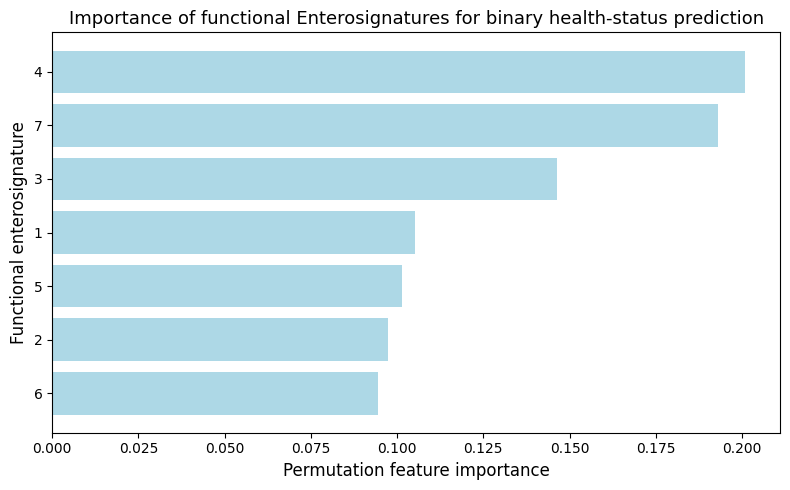

In [25]:
plt.figure(figsize=(8, 5))

PI_plot = PI_df.sort_values(by="import_mean", ascending=True).reset_index(drop=True)

plt.barh(range(len(PI_plot)), PI_plot["import_mean"], color='lightblue')
plt.yticks(range(len(PI_plot)), PI_plot["ES"])

plt.xlabel("Permutation feature importance", fontsize=12)
plt.ylabel("Functional enterosignature", fontsize=12)
plt.title("Importance of functional Enterosignatures for binary health-status prediction", fontsize=13)

plt.tight_layout()
plt.show()

### Q2PD Dysbiosis score

In [26]:
index_q2 = pd.read_csv(f"../results/q2/q2index.tsv", sep='\t', index_col=0)

samples_list = H_test_balanced.drop(['MM047.1', 'HSMA33MX', 'MM046.3']).index
index_q2 = index_q2.loc[samples_list]
index_q2

,Dysbiosis_score
H2M514911,0.271884
EGAR00001420486_9002000001343701,0.387531
FMT_03_t15,0.404424
SAMD00114875,0.305952
MH0398,0.420575
...,...
AS9raw,0.724565
M0x30MCx1586,0.407457
SID624_4M,0.325216
G80611,0.516559


In [27]:
y_q2 = pd.DataFrame()
y_q2["disease"] = metadata.loc[index_q2.index, "disease"]
y_q2 = (y_q2["disease"] != "healthy").astype(int)

# Dysbiosis_score <= 0.37 -> disease (1)
# Dysbiosis_score > 0.37  -> healthy (0)
index_q2["status"] = (index_q2["Dysbiosis_score"] < 0.37).astype(int)
y_q2_true = y_q2.to_numpy()
y_q2_pred = index_q2["status"].to_numpy()

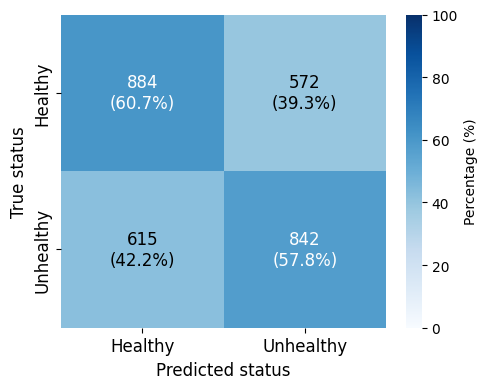

In [28]:
cm = confusion_matrix(y_q2_true, y_q2_pred)
plot_cm(cm, '../images/q2ES.png')

### ROC curves comparing the performance of the ES and Q2PD models. 

In [30]:
# ROC curve for ES
fpr_ES, tpr_ES, _ = roc_curve(y_test_balanced, y_prob)
auc_ES = auc(fpr_ES, tpr_ES)

# ROC curve for Q2PD
y_q2_pred = -index_q2["Dysbiosis_score"].to_numpy()
fpr_q2, tpr_q2, _ = roc_curve(y_q2_true, y_q2_pred)
auc_q2 = auc(fpr_q2, tpr_q2)

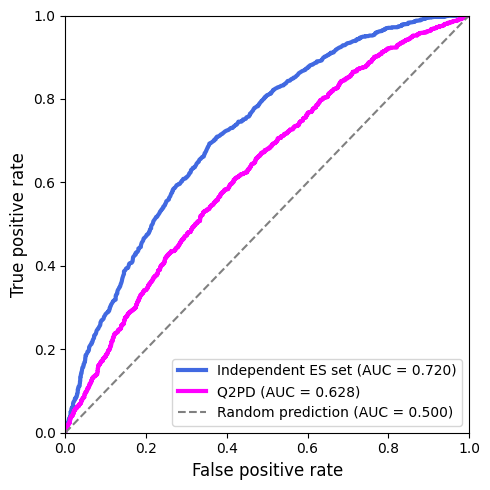

In [31]:
plt.figure(figsize=(5, 5))

plt.plot(fpr_ES, tpr_ES,
         linewidth=3,
         color='royalblue',
         label=f"Independent ES set (AUC = {auc_ES:.3f})")

plt.plot(fpr_q2, tpr_q2,
         linewidth=3,
         color="magenta",
         label=f"Q2PD (AUC = {auc_q2:.3f})")

# Random prediction
plt.plot([0, 1], [0, 1],
         linestyle="--",
         color='gray',
         linewidth=1.5,
         label="Random prediction (AUC = 0.500)")

plt.xlabel("False positive rate", fontsize=12)
plt.ylabel("True positive rate", fontsize=12)

plt.legend(loc="lower right")
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.savefig('../images/ROC.png', dpi=300)
plt.tight_layout()
plt.show()